# 0. Setting Up The Environment

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
rc = pd.read_parquet("data/raw/year=2022/round=1/R_race_control.parquet")
rc.head(5)

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap,Year,RoundNumber,EventName
0,2022-03-20 14:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1,2022,1,Bahrain Grand Prix
1,2022-03-20 14:30:01,Other,PIT EXIT CLOSED,None,None,None,NaN,None,1,2022,1,Bahrain Grand Prix
2,2022-03-20 14:45:05,Other,RISK OF RAIN FOR F1 RACE IS 0%,None,None,None,NaN,None,1,2022,1,Bahrain Grand Prix
3,2022-03-20 14:57:07,Drs,DRS DISABLED,DISABLED,None,None,NaN,None,1,2022,1,Bahrain Grand Prix
4,2022-03-20 15:03:35,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1,2022,1,Bahrain Grand Prix


In [12]:
df = pd.read_parquet("data/raw/year=2022/round=1/R.parquet")
df = df[df['LapNumber'] > 1]
df = df.sort_values(by=['DriverNumber_x', 'SessionTime'])
df.head(5)

,Date,SessionTime,Distance,Speed,Throttle,Brake,nGear,RPM,DRS,DriverNumber_x,...,Humidity,Pressure,WindSpeed,WindDirection,Rainfall,Year,RoundNumber,EventName,SessionType,EventFormat
674275,2022-03-20 15:05:15.668,0 days 01:04:15.651000,15867.955000,279.0,100.0,False,7,11145.0,1,1,...,26.0,1010.4,0.3,13,False,2022,1,Bahrain Grand Prix,Race,conventional
674276,2022-03-20 15:05:15.908,0 days 01:04:15.891000,15886.688333,281.0,100.0,False,7,11175.0,1,1,...,26.0,1010.4,0.3,13,False,2022,1,Bahrain Grand Prix,Race,conventional
674277,2022-03-20 15:05:16.268,0 days 01:04:16.251000,15914.988333,283.0,100.0,False,7,11288.0,1,1,...,26.0,1010.4,0.3,13,False,2022,1,Bahrain Grand Prix,Race,conventional
674278,2022-03-20 15:05:16.628,0 days 01:04:16.611000,15943.588333,286.0,100.0,False,7,11378.0,1,1,...,26.0,1010.4,0.3,13,False,2022,1,Bahrain Grand Prix,Race,conventional
674279,2022-03-20 15:05:16.828,0 days 01:04:16.811000,15959.588333,288.0,100.0,False,7,11397.0,1,1,...,26.0,1010.4,0.3,13,False,2022,1,Bahrain Grand Prix,Race,conventional


# 1. Mini EDA

## a) Track Conditions Analysis

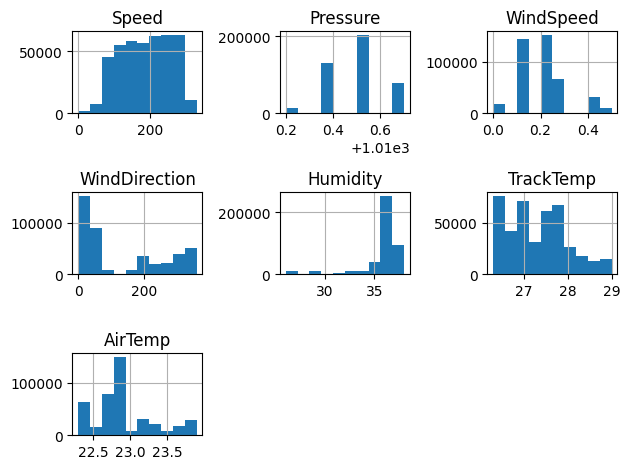

In [13]:
df[['Speed', 'Pressure', 'WindSpeed', 'WindDirection', 'Humidity', 'TrackTemp', 'AirTemp']].hist()
plt.tight_layout()
plt.show()

We can observe that Pressure and WindSpeed is quite discrete

## b) Racer Speed Analysis

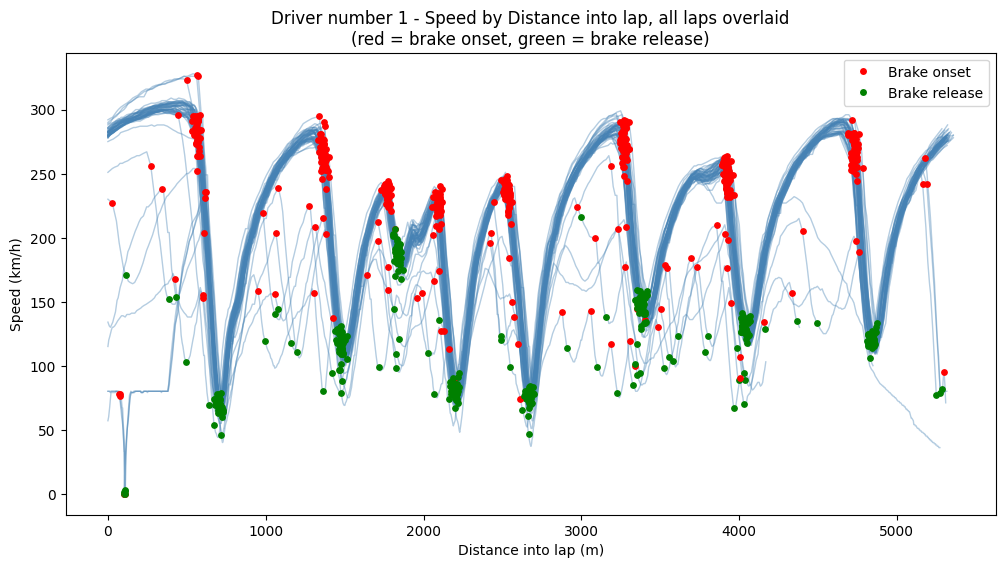

In [19]:
import matplotlib.pyplot as plt

driverNumber = '1'
mv_laps = df[df['DriverNumber_x'] == driverNumber].copy()

fig, ax = plt.subplots(figsize=(12, 6))

for lap_num, lap_data in mv_laps.groupby('LapNumber'):
    lap_data = lap_data.sort_values('Distance').reset_index(drop=True)
    relative_distance = lap_data['Distance'] - lap_data['Distance'].iloc[0]

    # base speed trace
    ax.plot(relative_distance, lap_data['Speed'], alpha=0.4, linewidth=1, color='steelblue')

    # detect brake transitions: False->True (onset) and True->False (release)
    brake = lap_data['Brake'].astype(bool)
    brake_diff = brake.astype(int).diff()

    onset_idx = brake_diff[brake_diff == 1].index      # False -> True
    release_idx = brake_diff[brake_diff == -1].index   # True -> False

    ax.scatter(relative_distance.loc[onset_idx], lap_data['Speed'].loc[onset_idx],
               color='red', s=15, zorder=3, marker='o')
    ax.scatter(relative_distance.loc[release_idx], lap_data['Speed'].loc[release_idx],
               color='green', s=15, zorder=3, marker='o')

ax.set_xlabel('Distance into lap (m)')
ax.set_ylabel('Speed (km/h)')
ax.set_title(f'Driver number {driverNumber} - Speed by Distance into lap, all laps overlaid\n(red = brake onset, green = brake release)')

# manual legend since we didn't label each scatter individually per lap
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Brake onset'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='Brake release'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.savefig(f'img/notebook/individual_total_laps/{driverNumber}.png', dpi=300, bbox_inches='tight')

plt.show()

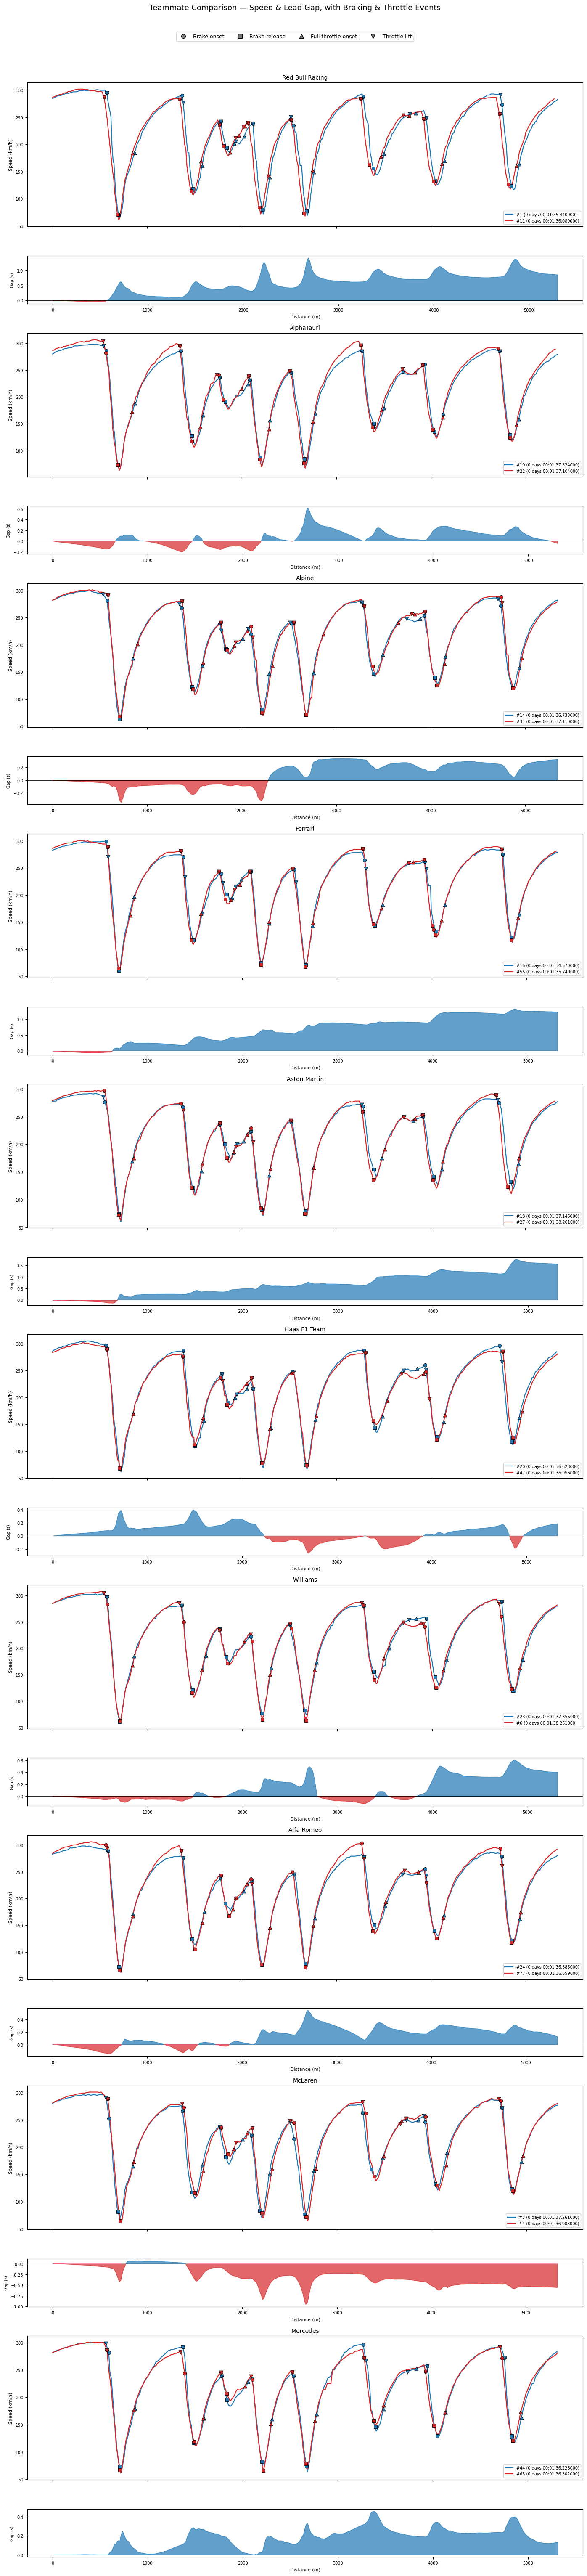

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- Step 1: compute best lap per driver ---
best_laps = {}  # driverNumber -> (best_lap_num, lap_data, best_time, team)

for driverNumber in df['DriverNumber_x'].unique():
    mv_laps = df[df['DriverNumber_x'] == driverNumber].copy()

    if mv_laps.empty or 'LapTime' not in mv_laps.columns:
        continue

    valid_laps = mv_laps.groupby('LapNumber')['LapTime'].first().dropna()
    if valid_laps.empty:
        continue

    best_lap_num = valid_laps.idxmin()
    best_time = valid_laps.min()

    lap_data = mv_laps[mv_laps['LapNumber'] == best_lap_num].sort_values('Distance').reset_index(drop=True)
    if lap_data.empty:
        continue

    team = lap_data['Team'].iloc[0] if 'Team' in lap_data.columns else 'Unknown'
    best_laps[driverNumber] = (best_lap_num, lap_data, best_time, team)

# --- Step 2: group drivers by team ---
teams = {}
for driverNumber, (best_lap_num, lap_data, best_time, team) in best_laps.items():
    teams.setdefault(team, []).append((driverNumber, best_lap_num, lap_data, best_time))

team_pairs = {team: drivers for team, drivers in teams.items() if len(drivers) == 2}
n_teams = len(team_pairs)

driver_colors = ['#1f77b4', '#d62728']  # teammate 1 = blue, teammate 2 = red


def get_cumulative_time(lap_data):
    """Return cumulative time (seconds) at each row, starting from 0.
    Uses a real Time column if present, else derives it from Speed/Distance."""
    if 'Time' in lap_data.columns:
        t = lap_data['Time']
        if np.issubdtype(t.dtype, np.timedelta64):
            t = t.dt.total_seconds()
        return (t - t.iloc[0]).to_numpy()
    else:
        dist = lap_data['Distance'].to_numpy()
        speed_ms = np.clip(lap_data['Speed'].to_numpy() / 3.6, 1e-3, None)  # km/h -> m/s, avoid /0
        dt = np.diff(dist) / speed_ms[:-1]
        return np.concatenate([[0], np.cumsum(dt)])


# --- Step 3: plot — 2 rows per team (speed on top, lead ribbon below) ---
fig, axes = plt.subplots(
    n_teams * 2, 1, figsize=(14, 6 * n_teams),
    gridspec_kw={'height_ratios': [3, 1] * n_teams}
)

for pair_idx, (team, drivers) in enumerate(team_pairs.items()):
    ax_speed = axes[pair_idx * 2]
    ax_lead = axes[pair_idx * 2 + 1]

    driver_traces = []  # (driverNumber, relative_distance, lap_data, cum_time)

    for driver_color, (driverNumber, best_lap_num, lap_data, best_time) in zip(driver_colors, drivers):
        relative_distance = (lap_data['Distance'] - lap_data['Distance'].iloc[0]).to_numpy()

        # base speed trace
        ax_speed.plot(relative_distance, lap_data['Speed'], linewidth=1.6, color=driver_color,
                      label=f'#{driverNumber} ({best_time})')

        # brake onset/release
        brake = lap_data['Brake'].astype(bool)
        brake_diff = brake.astype(int).diff()
        brake_onset_idx = brake_diff[brake_diff == 1].index
        brake_release_idx = brake_diff[brake_diff == -1].index

        ax_speed.scatter(lap_data['Distance'].loc[brake_onset_idx] - lap_data['Distance'].iloc[0],
                          lap_data['Speed'].loc[brake_onset_idx],
                          facecolor=driver_color, edgecolor='black', marker='o', s=35, zorder=3, linewidths=0.6)
        ax_speed.scatter(lap_data['Distance'].loc[brake_release_idx] - lap_data['Distance'].iloc[0],
                          lap_data['Speed'].loc[brake_release_idx],
                          facecolor=driver_color, edgecolor='black', marker='s', s=35, zorder=3, linewidths=0.6)

        # throttle lift/full-throttle-onset
        if 'Throttle' in lap_data.columns:
            full_throttle = lap_data['Throttle'] >= 99
            throttle_diff = full_throttle.astype(int).diff()
            throttle_onset_idx = throttle_diff[throttle_diff == 1].index
            throttle_lift_idx = throttle_diff[throttle_diff == -1].index

            ax_speed.scatter(lap_data['Distance'].loc[throttle_onset_idx] - lap_data['Distance'].iloc[0],
                              lap_data['Speed'].loc[throttle_onset_idx],
                              facecolor=driver_color, edgecolor='black', marker='^', s=40, zorder=3, linewidths=0.6)
            ax_speed.scatter(lap_data['Distance'].loc[throttle_lift_idx] - lap_data['Distance'].iloc[0],
                              lap_data['Speed'].loc[throttle_lift_idx],
                              facecolor=driver_color, edgecolor='black', marker='v', s=40, zorder=3, linewidths=0.6)

        cum_time = get_cumulative_time(lap_data)
        driver_traces.append((driverNumber, relative_distance, cum_time))

    ax_speed.set_title(team, fontsize=10)
    ax_speed.set_ylabel('Speed (km/h)', fontsize=8)
    ax_speed.legend(fontsize=7, loc='lower right')
    ax_speed.tick_params(labelsize=7, labelbottom=False)  # hide x labels, shared with ribbon below

    # --- lead ribbon: interpolate both drivers onto a common distance grid ---
    if len(driver_traces) == 2:
        (num_blue, dist_blue, time_blue), (num_red, dist_red, time_red) = driver_traces

        common_max = min(dist_blue.max(), dist_red.max())
        common_grid = np.linspace(0, common_max, 400)

        time_blue_interp = np.interp(common_grid, dist_blue, time_blue)
        time_red_interp = np.interp(common_grid, dist_red, time_red)

        # positive = blue reached this point sooner (blue leads); negative = red leads
        gap = time_red_interp - time_blue_interp

        ax_lead.fill_between(common_grid, gap, 0, where=(gap >= 0),
                              color=driver_colors[0], alpha=0.7, interpolate=True)
        ax_lead.fill_between(common_grid, gap, 0, where=(gap <= 0),
                              color=driver_colors[1], alpha=0.7, interpolate=True)
        ax_lead.axhline(0, color='black', linewidth=0.6)
        ax_lead.set_ylabel('Gap (s)', fontsize=7)

    ax_lead.set_xlabel('Distance (m)', fontsize=8)
    ax_lead.tick_params(labelsize=7)

# shared legend for event markers
event_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=7, label='Brake onset'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=7, label='Brake release'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=7, label='Full throttle onset'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=7, label='Throttle lift'),
]
fig.legend(handles=event_elements, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4, fontsize=9)

fig.suptitle('Teammate Comparison — Speed & Lead Gap, with Braking & Throttle Events', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'img/notebook/teammate_comparison/speed-leadGap.png', dpi=300, bbox_inches='tight')

plt.show()

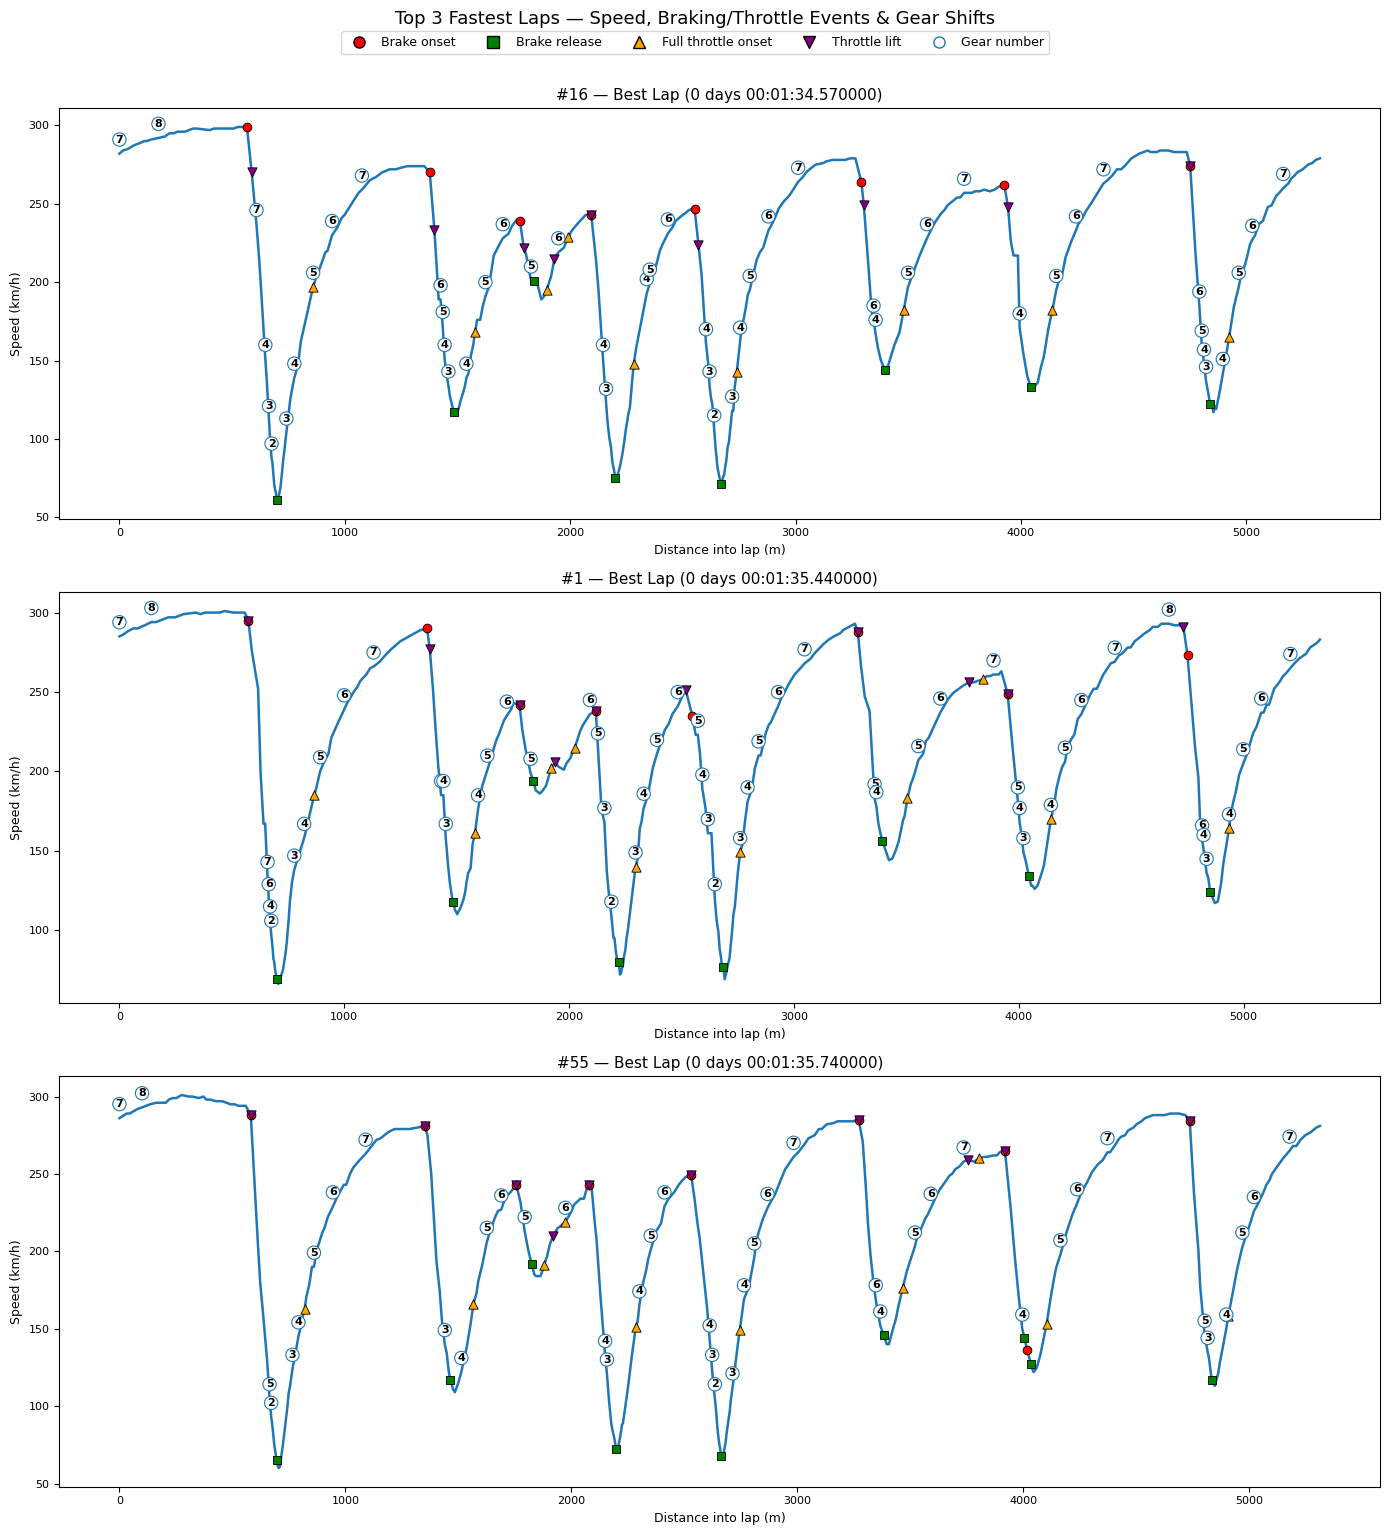

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- Step 1: compute best lap per driver ---
best_laps = {}  # driverNumber -> (best_lap_num, lap_data, best_time)

for driverNumber in df['DriverNumber_x'].unique():
    mv_laps = df[df['DriverNumber_x'] == driverNumber].copy()

    if mv_laps.empty or 'LapTime' not in mv_laps.columns:
        continue

    valid_laps = mv_laps.groupby('LapNumber')['LapTime'].first().dropna()
    if valid_laps.empty:
        continue

    best_lap_num = valid_laps.idxmin()
    best_time = valid_laps.min()

    lap_data = mv_laps[mv_laps['LapNumber'] == best_lap_num].sort_values('Distance').reset_index(drop=True)
    if lap_data.empty:
        continue

    best_laps[driverNumber] = (best_lap_num, lap_data, best_time)

# --- Step 2: keep only the top 3 fastest ---
top3_drivers = sorted(best_laps.items(), key=lambda kv: kv[1][2])[:3]

driver_color = '#1f77b4'  # single color per subplot; change if you want per-driver colors

# --- Step 3: plot — 1 subplot per driver, stacked ---
fig, axes = plt.subplots(len(top3_drivers), 1, figsize=(14, 5 * len(top3_drivers)))
if len(top3_drivers) == 1:
    axes = [axes]

for ax, (driverNumber, (best_lap_num, lap_data, best_time)) in zip(axes, top3_drivers):
    relative_distance = (lap_data['Distance'] - lap_data['Distance'].iloc[0]).to_numpy()
    speed = lap_data['Speed'].to_numpy()

    # base speed trace
    ax.plot(relative_distance, speed, linewidth=1.8, color=driver_color)

    # --- brake onset/release ---
    brake = lap_data['Brake'].astype(bool)
    brake_diff = brake.astype(int).diff()
    brake_onset_idx = brake_diff[brake_diff == 1].index
    brake_release_idx = brake_diff[brake_diff == -1].index

    ax.scatter(lap_data['Distance'].loc[brake_onset_idx] - lap_data['Distance'].iloc[0],
               lap_data['Speed'].loc[brake_onset_idx],
               facecolor='red', edgecolor='black', marker='o', s=40, zorder=3, linewidths=0.6)
    ax.scatter(lap_data['Distance'].loc[brake_release_idx] - lap_data['Distance'].iloc[0],
               lap_data['Speed'].loc[brake_release_idx],
               facecolor='green', edgecolor='black', marker='s', s=40, zorder=3, linewidths=0.6)

    # --- throttle lift/full-throttle-onset ---
    if 'Throttle' in lap_data.columns:
        full_throttle = lap_data['Throttle'] >= 99
        throttle_diff = full_throttle.astype(int).diff()
        throttle_onset_idx = throttle_diff[throttle_diff == 1].index
        throttle_lift_idx = throttle_diff[throttle_diff == -1].index

        ax.scatter(lap_data['Distance'].loc[throttle_onset_idx] - lap_data['Distance'].iloc[0],
                   lap_data['Speed'].loc[throttle_onset_idx],
                   facecolor='orange', edgecolor='black', marker='^', s=45, zorder=3, linewidths=0.6)
        ax.scatter(lap_data['Distance'].loc[throttle_lift_idx] - lap_data['Distance'].iloc[0],
                   lap_data['Speed'].loc[throttle_lift_idx],
                   facecolor='purple', edgecolor='black', marker='v', s=45, zorder=3, linewidths=0.6)

    # --- gear indicator: annotate every gear change with the new gear number, on the line ---
    if 'nGear' in lap_data.columns or 'Gear' in lap_data.columns:
        gear_col = 'nGear' if 'nGear' in lap_data.columns else 'Gear'
        gear = lap_data[gear_col].to_numpy()
        gear_change_idx = np.where(np.diff(gear) != 0)[0] + 1  # index where the new gear starts
        # also include the very first point so you see the starting gear
        gear_change_idx = np.concatenate([[0], gear_change_idx])

        for idx in gear_change_idx:
            ax.annotate(
                str(int(gear[idx])),
                xy=(relative_distance[idx], speed[idx]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle='circle,pad=0.15', facecolor='white', edgecolor=driver_color, linewidth=0.8)
            )

    ax.set_title(f'#{driverNumber} — Best Lap ({best_time})', fontsize=11)
    ax.set_xlabel('Distance into lap (m)', fontsize=9)
    ax.set_ylabel('Speed (km/h)', fontsize=9)
    ax.tick_params(labelsize=8)

# shared legend for event markers + gear indicator
event_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markersize=8, label='Brake onset'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='green', markeredgecolor='black', markersize=8, label='Brake release'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='orange', markeredgecolor='black', markersize=8, label='Full throttle onset'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='purple', markeredgecolor='black', markersize=8, label='Throttle lift'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=driver_color, markersize=8, label='Gear number'),
]
fig.legend(handles=event_elements, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=5, fontsize=9)

fig.suptitle('Top 3 Fastest Laps — Speed, Braking/Throttle Events & Gear Shifts', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'img/notebook/top3_fastestLaps_Indicator.png', dpi=300, bbox_inches='tight')

plt.show()

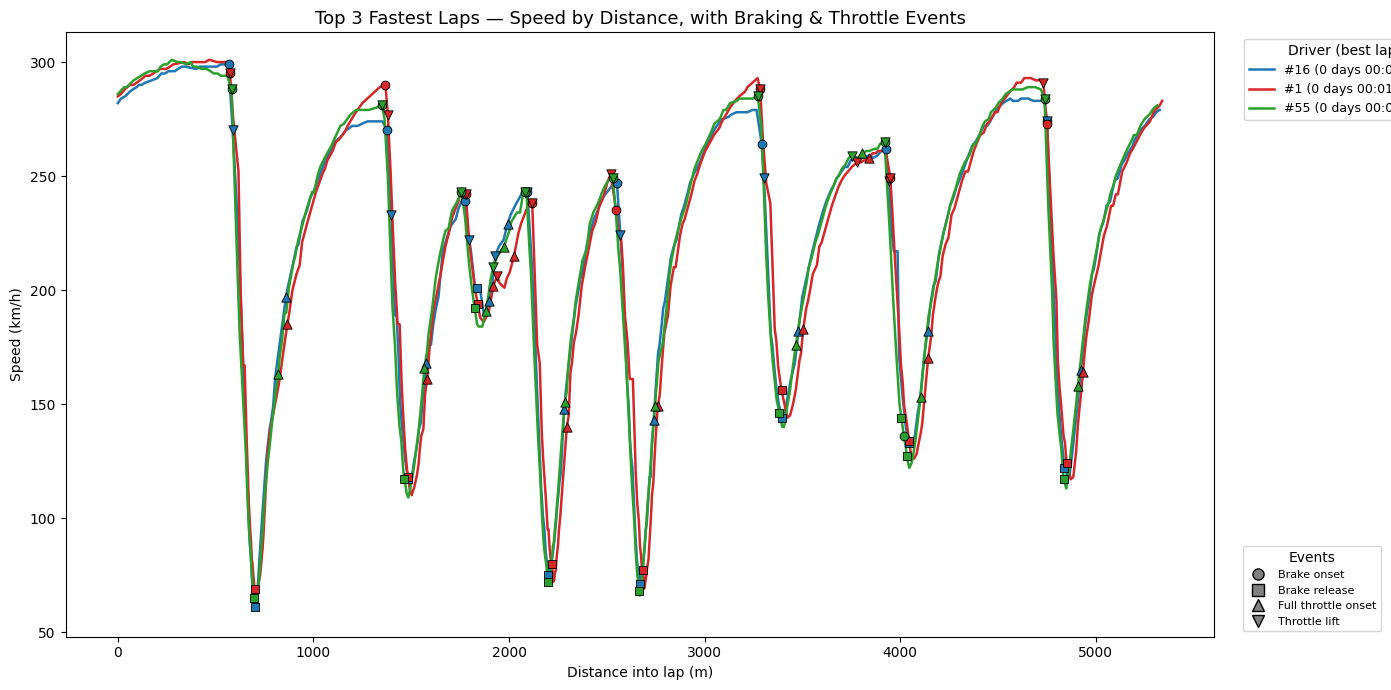

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Step 1: compute best lap per driver ---
best_laps = {}  # driverNumber -> (best_lap_num, lap_data, best_time)

for driverNumber in df['DriverNumber_x'].unique():
    mv_laps = df[df['DriverNumber_x'] == driverNumber].copy()

    if mv_laps.empty or 'LapTime' not in mv_laps.columns:
        continue

    valid_laps = mv_laps.groupby('LapNumber')['LapTime'].first().dropna()
    if valid_laps.empty:
        continue

    best_lap_num = valid_laps.idxmin()
    best_time = valid_laps.min()

    lap_data = mv_laps[mv_laps['LapNumber'] == best_lap_num].sort_values('Distance').reset_index(drop=True)
    if lap_data.empty:
        continue

    best_laps[driverNumber] = (best_lap_num, lap_data, best_time)

# --- Step 2: keep only the top 3 fastest ---
top3_drivers = sorted(best_laps.items(), key=lambda kv: kv[1][2])[:3]

# --- Step 3: plot — all 3 overlaid on one axes ---
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#1f77b4', '#d62728', '#2ca02c']  # driver 1 = blue, 2 = red, 3 = green

for driver_color, (driverNumber, (best_lap_num, lap_data, best_time)) in zip(colors, top3_drivers):
    relative_distance = (lap_data['Distance'] - lap_data['Distance'].iloc[0]).to_numpy()

    # base speed trace
    ax.plot(relative_distance, lap_data['Speed'], linewidth=1.8, color=driver_color,
             label=f'#{driverNumber} ({best_time})')

    # --- brake onset/release ---
    brake = lap_data['Brake'].astype(bool)
    brake_diff = brake.astype(int).diff()
    brake_onset_idx = brake_diff[brake_diff == 1].index
    brake_release_idx = brake_diff[brake_diff == -1].index

    ax.scatter(lap_data['Distance'].loc[brake_onset_idx] - lap_data['Distance'].iloc[0],
               lap_data['Speed'].loc[brake_onset_idx],
               facecolor=driver_color, edgecolor='black', marker='o', s=40, zorder=3, linewidths=0.6)
    ax.scatter(lap_data['Distance'].loc[brake_release_idx] - lap_data['Distance'].iloc[0],
               lap_data['Speed'].loc[brake_release_idx],
               facecolor=driver_color, edgecolor='black', marker='s', s=40, zorder=3, linewidths=0.6)

    # --- throttle lift/full-throttle-onset ---
    if 'Throttle' in lap_data.columns:
        full_throttle = lap_data['Throttle'] >= 99
        throttle_diff = full_throttle.astype(int).diff()
        throttle_onset_idx = throttle_diff[throttle_diff == 1].index
        throttle_lift_idx = throttle_diff[throttle_diff == -1].index

        ax.scatter(lap_data['Distance'].loc[throttle_onset_idx] - lap_data['Distance'].iloc[0],
                   lap_data['Speed'].loc[throttle_onset_idx],
                   facecolor=driver_color, edgecolor='black', marker='^', s=45, zorder=3, linewidths=0.6)
        ax.scatter(lap_data['Distance'].loc[throttle_lift_idx] - lap_data['Distance'].iloc[0],
                   lap_data['Speed'].loc[throttle_lift_idx],
                   facecolor=driver_color, edgecolor='black', marker='v', s=45, zorder=3, linewidths=0.6)

ax.set_xlabel('Distance into lap (m)', fontsize=10)
ax.set_ylabel('Speed (km/h)', fontsize=10)
ax.set_title('Top 3 Fastest Laps — Speed by Distance, with Braking & Throttle Events', fontsize=13)

# legend 1: drivers (color-coded)
driver_legend = ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, title='Driver (best lap time)')
ax.add_artist(driver_legend)

# legend 2: event marker shapes
event_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=8, label='Brake onset'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=8, label='Brake release'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=8, label='Full throttle onset'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=8, label='Throttle lift'),
]
ax.legend(handles=event_elements, loc='lower left', bbox_to_anchor=(1.02, 0), fontsize=8, title='Events')

plt.tight_layout()
plt.savefig(f'img/notebook/top3_fastestLaps_noIndicator.png', dpi=300, bbox_inches='tight')

plt.show()